<a href="https://colab.research.google.com/github/kingnathan-15/showtrack/blob/main/Merged_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TV Show Clustering and Recommendation Across Streaming Platforms
This model aims to use kmeans clustering and cosine similarity to create an algorithm that can be used to recommend a set of similar TV shows that the user may like.

## 1. Importing Datasets

For this model we will use Kaggle User shivamb's datasets for the three major streaming providers:
- Netflix
- Amazon
- Disney+

After the import, we merge them into one unified catalog.

In [61]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")
path2 = kagglehub.dataset_download("shivamb/amazon-prime-movies-and-tv-shows")
path3 = kagglehub.dataset_download("shivamb/disney-movies-and-tv-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Using Colab cache for faster access to the 'amazon-prime-movies-and-tv-shows' dataset.
Using Colab cache for faster access to the 'disney-movies-and-tv-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [62]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [63]:
netflix_catalog = pd.read_csv(path+'/netflix_titles.csv')
amazon_catalog = pd.read_csv(path2+'/amazon_prime_titles.csv')
disney_catalog = pd.read_csv(path3+'/disney_plus_titles.csv')

In [64]:
amazon_catalog["platform"]="Amazon"
disney_catalog["platform"]="Disney"
netflix_catalog["platform"]="Netflix"
netflix_catalog.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Netflix
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Netflix
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Netflix
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Netflix


In [65]:
catalog = pd.concat([amazon_catalog, disney_catalog, netflix_catalog], ignore_index=True)
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19925 entries, 0 to 19924
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       19925 non-null  object
 1   type          19925 non-null  object
 2   title         19925 non-null  object
 3   director      14735 non-null  object
 4   cast          17677 non-null  object
 5   country       9879 non-null   object
 6   date_added    10399 non-null  object
 7   release_year  19925 non-null  int64 
 8   rating        19581 non-null  object
 9   duration      19922 non-null  object
 10  listed_in     19925 non-null  object
 11  description   19925 non-null  object
 12  platform      19925 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.0+ MB


In [66]:
catalog = catalog[catalog['type']== 'TV Show']
catalog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4928 entries, 17 to 19921
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4928 non-null   object
 1   type          4928 non-null   object
 2   title         4928 non-null   object
 3   director      230 non-null    object
 4   cast          4038 non-null   object
 5   country       2673 non-null   object
 6   date_added    3200 non-null   object
 7   release_year  4928 non-null   int64 
 8   rating        4918 non-null   object
 9   duration      4928 non-null   object
 10  listed_in     4928 non-null   object
 11  description   4928 non-null   object
 12  platform      4928 non-null   object
dtypes: int64(1), object(12)
memory usage: 539.0+ KB


In [67]:
catalog.drop(['type', 'director', 'show_id', 'date_added'], axis = 1, inplace = True)
catalog.drop_duplicates()
catalog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4928 entries, 17 to 19921
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         4928 non-null   object
 1   cast          4038 non-null   object
 2   country       2673 non-null   object
 3   release_year  4928 non-null   int64 
 4   rating        4918 non-null   object
 5   duration      4928 non-null   object
 6   listed_in     4928 non-null   object
 7   description   4928 non-null   object
 8   platform      4928 non-null   object
dtypes: int64(1), object(8)
memory usage: 385.0+ KB


In [68]:
catalog.head(5)

,title,cast,country,release_year,rating,duration,listed_in,description,platform
17,Zoo Babies,Narrator - Gillian Barlett,NaN,2008,ALL,1 Season,"Kids, Special Interest",A heart warming and inspiring series that welc...,Amazon
18,Zoë Coombs Marr: Bossy Bottom,Zoë Coombs Marr,NaN,2020,18+,1 Season,"Comedy, Talk Show and Variety",Zoë Coombs Marr has been on hiatus. Sort of. F...,Amazon
20,Zoboomafoo,NaN,NaN,2001,TV-Y,1 Season,Kids,Chris and Martin Kratt bring their enthusiasm ...,Amazon
21,Zo Zo Zombie: Mini-Series,"Alex Cazares, Ben Diskin, Cristina Vee, Erika ...",NaN,2020,TV-Y7,1 Season,"Action, Anime, Comedy","Zo Zo Zombie is our undead hero who, with his ...",Amazon
23,ZeroZeroZero,"ANDREA RISEBOROUGH, HAROLD TORRES, CLAUDIA PIN...",Italy,2020,18+,1 Season,TV Shows,ZeroZeroZero series follows the journey of a c...,Amazon


In [69]:
catalog['duration'].value_counts()
catalog['duration'] = catalog['duration'].str.extract(r'(\d+)').astype(int)
catalog.head(5)

,title,cast,country,release_year,rating,duration,listed_in,description,platform
17,Zoo Babies,Narrator - Gillian Barlett,NaN,2008,ALL,1,"Kids, Special Interest",A heart warming and inspiring series that welc...,Amazon
18,Zoë Coombs Marr: Bossy Bottom,Zoë Coombs Marr,NaN,2020,18+,1,"Comedy, Talk Show and Variety",Zoë Coombs Marr has been on hiatus. Sort of. F...,Amazon
20,Zoboomafoo,NaN,NaN,2001,TV-Y,1,Kids,Chris and Martin Kratt bring their enthusiasm ...,Amazon
21,Zo Zo Zombie: Mini-Series,"Alex Cazares, Ben Diskin, Cristina Vee, Erika ...",NaN,2020,TV-Y7,1,"Action, Anime, Comedy","Zo Zo Zombie is our undead hero who, with his ...",Amazon
23,ZeroZeroZero,"ANDREA RISEBOROUGH, HAROLD TORRES, CLAUDIA PIN...",Italy,2020,18+,1,TV Shows,ZeroZeroZero series follows the journey of a c...,Amazon


In [70]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(catalog['listed_in'].str.split(', '))

catalog = catalog.reset_index(drop=True)

genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_)
genre_df['Duration'] = catalog['duration']

In [71]:
genre_df['Duration'].isna().sum()

np.int64(0)

In [72]:
genre_df.head()

,Action,Action-Adventure,Adventure,Animals & Nature,Animation,Anime,Anime Series,Anthology,Arthouse,Arts,...,Talk Show,Talk Show and Variety,Teen TV Shows,Travel,Unscripted,Variety,Western,Young Adult Audience,and Culture,Duration
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


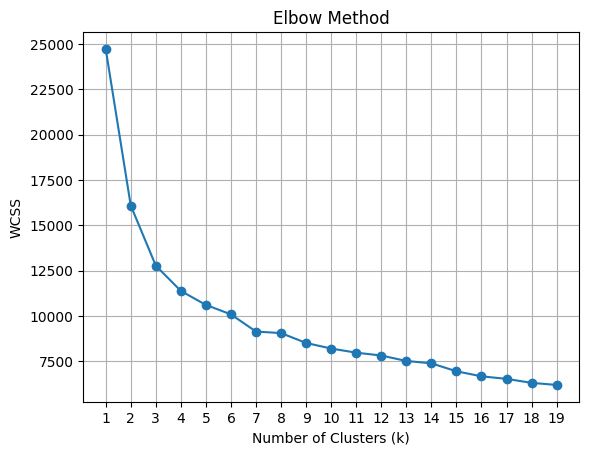

In [73]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(genre_df)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [74]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
catalog['genre_cluster'] = kmeans.fit_predict(genre_matrix)

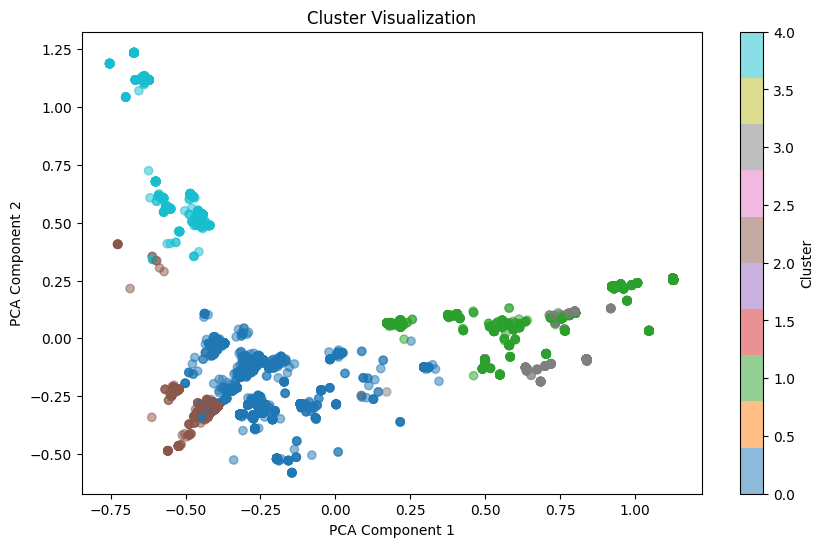

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(genre_matrix)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=catalog['genre_cluster'], cmap='tab10', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('Cluster Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()